In [1]:
import numpy as np
from pathlib import Path
import numpy as np
from scipy.signal import butter, sosfiltfilt
from fontTools.diff import color
import matplotlib.pyplot as plt
from numpy.ma.core import size

DATA_DIR = Path(r"C:\Users\asus\PycharmProjects\UltrasonicProject_ML\data")

data = np.load(
    DATA_DIR / "Pk050_3D_Dataset_Long_Rot00.npy",
    mmap_mode="r"
)

X = np.load(DATA_DIR / "X-values.npy")
Y = np.load(DATA_DIR / "Y-values.npy")
Z = np.load(DATA_DIR / "Z-values.npy")

valid_mask = np.any(data != 0, axis=2)

## Get features

In [2]:
points = {
    (250, 60): 571.3,
    (750, 60): 452.0,
    (1250, 60): 330.9,
    (1750, 60): 210.8
}

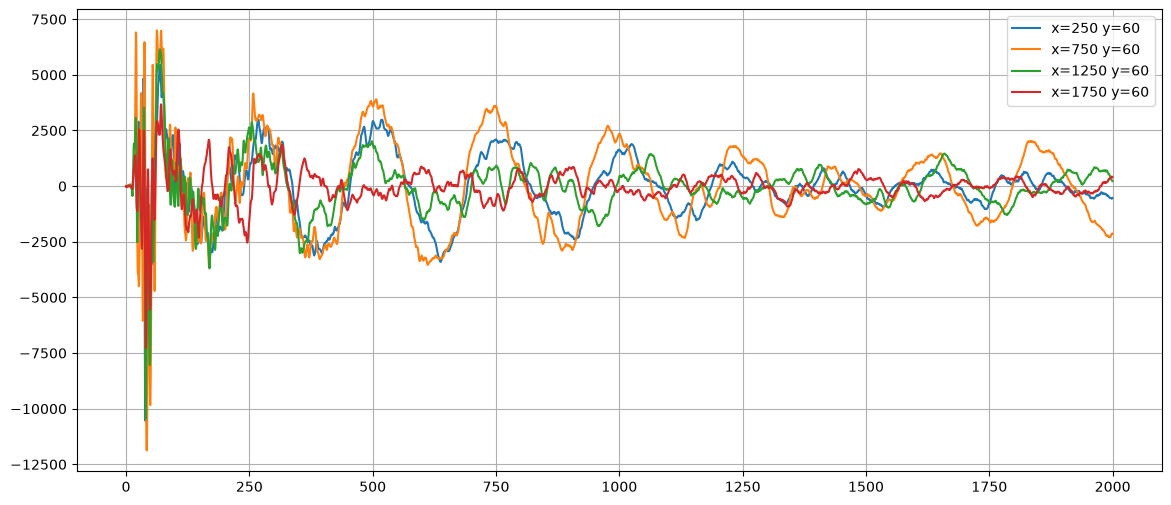

In [3]:
plt.figure(figsize=(14, 6))
for x, y in points:
    x_index = np.where( X == x )[0][0]
    y_index = np.where( Y == y )[0][0]
    a_scan = data[x_index, y_index, :]
    plt.plot(Z , a_scan, label=f'x={x} y={y}')
plt.grid()
plt.legend()
plt.savefig('a_scan.png')
plt.show()

## Butterworth Band-pass

In [4]:
def butterworth_bandpass(signal,fs,lowcut,highcut,order=4,padtype="odd"):

    signal = np.asarray(signal, dtype=float)
    
    if signal.ndim != 1:
        raise ValueError("signal باید یک آرایه‌ی یک‌بعدی باشد.")
    if len(signal) < 10:
        raise ValueError("طول سیگنال برای فیلتر کردن کافی نیست.")
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("fs باید یک عدد مثبت و معتبر باشد.")
    if not isinstance(order, int) or order < 1:
        raise ValueError("order باید یک عدد صحیح بزرگ‌تر از صفر باشد.")
    if not np.isfinite(lowcut) or not np.isfinite(highcut):
        raise ValueError("فرکانس‌های قطع باید مقدار معتبر داشته باشند.")

    nyquist = fs / 2

    if lowcut <= 0:
        raise ValueError("lowcut باید بزرگ‌تر از صفر باشد.")
    if highcut >= nyquist:
        raise ValueError("highcut باید کمتر از فرکانس Nyquist باشد.")
    if lowcut >= highcut:
        raise ValueError("lowcut باید کمتر از highcut باشد.")

    sos = butter(N=order, Wn=[lowcut, highcut], btype="bandpass", fs=fs,output="sos")
    filtered_signal = sosfiltfilt(sos, signal, padtype=padtype)

    return filtered_signal

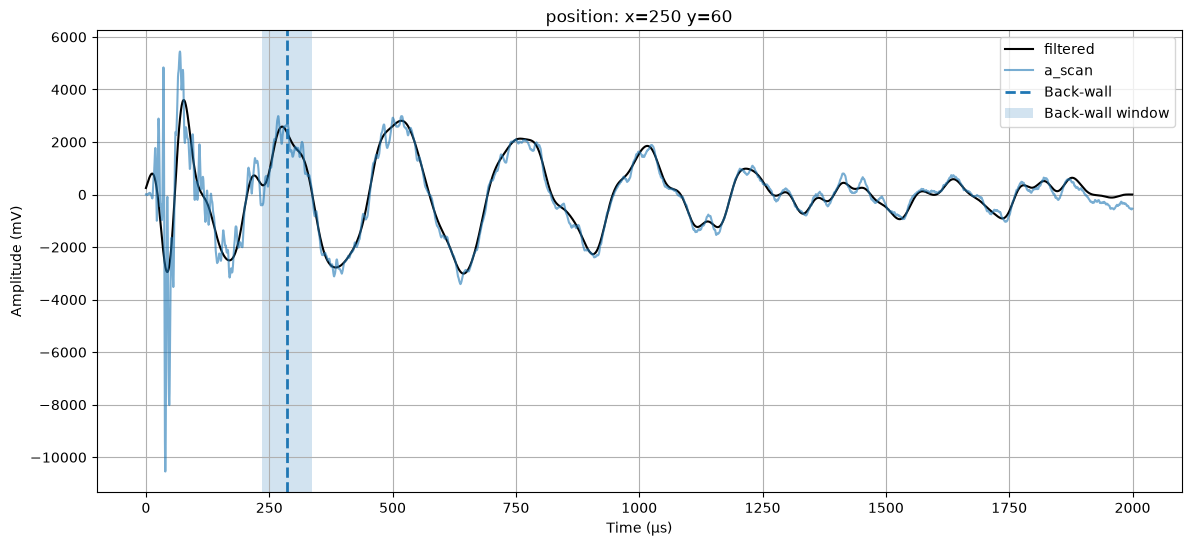

In [5]:
fs = 2e6       # 2 MHz sampling rate
a_scan = data[25, 6, :]

filtered = butterworth_bandpass(
    a_scan,
    fs=2e6,
    lowcut=500,
    highcut=2e4
)


plt.figure(figsize=(14, 6))
plt.plot(Z, filtered, label='filtered', color='black')
plt.plot(Z, a_scan, label='a_scan', alpha= 0.6)

t_backwall = 285.65

plt.axvline(
    x=t_backwall,
    linestyle='--',
    linewidth=2,
    label='Back-wall'
)

plt.axvspan(
    t_backwall - 50,
    t_backwall + 50,
    alpha=0.2,
    label='Back-wall window'
)

plt.grid()

plt.title('position: x=250 y=60')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (mV)')
plt.legend()

plt.savefig('a_scan.png')
plt.show()

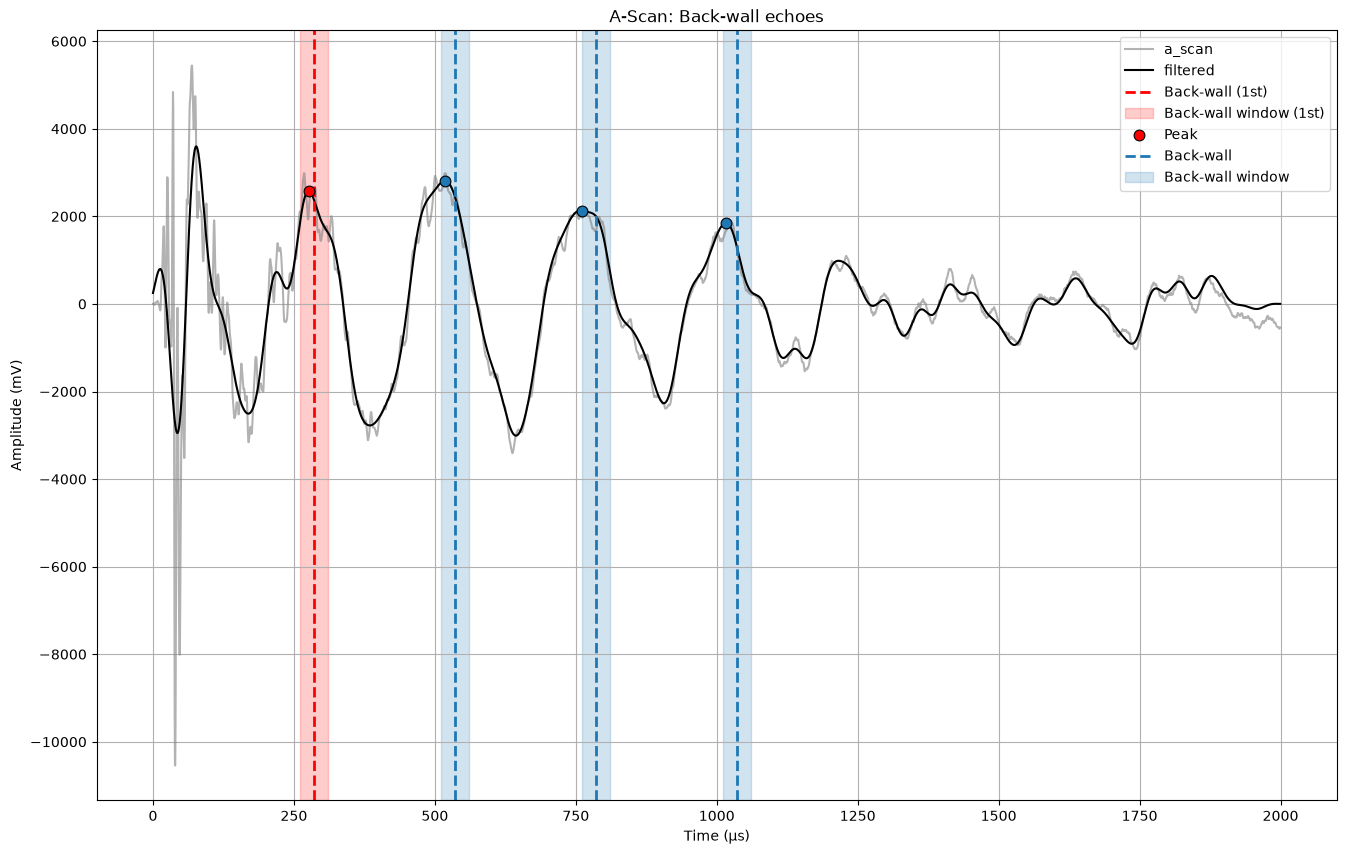

In [6]:
# -----------------------------
# Back-wall echo parameters
# -----------------------------
a_scan = data[25, 6, :]
time_us = Z
first_backwall = 285.65   # µs
echo_spacing = 250.0      # µs
window_width = 10        # samples

# Sampling rate
fs = 2_000_000            # Hz
Ts = 1 / fs               # seconds
Ts_us = Ts * 1e6          # 0.5 µs

# 20 samples = 10 µs total width
window_time = window_width * Ts_us
half_window = window_time / 2

# فقط ۴ اکو اول را می‌خواهیم (اولی قرمز، سه‌تای بعدی رنگ عادی)
n_echoes = 4

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16, 10))
plt.plot(time_us, a_scan, label='a_scan', color='gray', alpha=0.6)
plt.plot(time_us, filtered, label='filtered', color='black')

# -----------------------------
# Mark first n_echoes Back-wall echoes
# -----------------------------
for echo_number in range(1, n_echoes + 1):
    backwall_time = first_backwall + (echo_number - 1) * echo_spacing

    # رنگ: اولی قرمز، بقیه آبی پیش‌فرض
    color = 'red' if echo_number == 1 else 'tab:blue'

    # خط Back-wall
    plt.axvline(
        x=backwall_time,
        color=color,
        linestyle='--',
        linewidth=2,
        label='Back-wall (1st)' if echo_number == 1 else ('Back-wall' if echo_number == 2 else None)
    )

    # هاله اطراف Back-wall
    win_start = backwall_time - half_window * 10
    win_end = backwall_time + half_window * 10

    plt.axvspan(
        win_start,
        win_end,
        color=color,
        alpha=0.2,
        label='Back-wall window (1st)' if echo_number == 1 else ('Back-wall window' if echo_number == 2 else None)
    )

    # -----------------------------
    # پیدا کردن نقطه پیک داخل این هاله
    # -----------------------------
    mask = (time_us >= win_start) & (time_us <= win_end)
    if np.any(mask):
        window_times = time_us[mask]
        window_vals = filtered[mask]

        peak_idx = np.argmax(window_vals)  # پیک بر اساس بیشترین دامنه (مثبت یا منفی)
        peak_time = window_times[peak_idx]
        peak_val = window_vals[peak_idx]

        plt.scatter(
            peak_time,
            peak_val,
            color=color,
            marker='o',
            s=60,
            zorder=5,
            edgecolor='black',
            linewidth=0.8,
            label='Peak' if echo_number == 1 else None
        )

plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (mV)')
plt.title('A-Scan: Back-wall echoes')
plt.legend()
plt.grid()
plt.savefig('a_scan__1.png')
plt.show()

In [7]:
def get_backwall_echoes(x_idx, y_idx, first_backwall, half_window=50, max_echoes=3):
    """
    ورودی:
        x_idx, y_idx      : موقعیت A-scan مورد نظر در آرایه data
        first_backwall    : زمان اولین بک‌وال (بر حسب همون واحد time_us)
        half_window       : نیم‌پنجره‌ی برش نهایی حول هر هاله
        max_echoes        : حداکثر تعداد هاله برای استخراج
    خروجی:
        دیکشنری {'echo_1': (time_window, signal_window), ...}
    """
    signal = data[x_idx, y_idx, :]
    echoes = {}

    for n in range(1, max_echoes + 1):
        approx_center = n * first_backwall

        # پنجره‌ی جستجوی محلی (بزرگ‌تر از half_window نهایی) حول تخمین اولیه
        search_mask = (time_us >= approx_center - 2*half_window) & \
                      (time_us <= approx_center + 2*half_window)
        search_sig, search_t = signal[search_mask], time_us[search_mask]

        if len(search_sig) == 0:
            break

        # پیدا کردن پیک واقعی (بیشترین قدرمطلق دامنه) در بازه‌ی جستجو
        peak_idx = np.argmax(search_sig)
        real_center = search_t[peak_idx]   # <-- زمان پیک، نه دامنه‌ش

        # برش نهایی حول زمان پیک واقعی
        final_mask = (time_us >= real_center - half_window) & \
                     (time_us <= real_center + half_window)
        sig_win, t_win = signal[final_mask], time_us[final_mask]

        if len(t_win) == 0:
            break

        echoes[f'echo_{n}'] = (t_win, sig_win)

    return echoes

In [8]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_a_scan(x, y):
    a_scan = data[x, y, :]
    plt.figure(figsize=(16, 10))

    filtered = butterworth_bandpass(
        a_scan,
        fs=2e6,
        lowcut=0.002e6,
        highcut=0.02e6
    )

    echoes = get_backwall_echoes(
        x_idx=x, y_idx=y,
        first_backwall=285.65,
        half_window= 30
    )

    plt.plot(Z, a_scan, label='a_scan', color='gray', )
    plt.plot(Z, filtered, label='filtered', color='black')

    for i in echoes:
        plt.plot(echoes[i][0], echoes[i][1], label=f'{i}', linewidth=3, )  # color='red'

    plt.xlabel('Time (µs)')
    plt.ylabel('Amplitude (mV)')
    plt.title(f'A-Scan: Back-wall echoes (x={x}, y={y})')
    plt.legend()
    plt.grid()
    signal = a_scan = data[x, y, :] ; time = Z
    
    plt.show()


# اسلایدر برای x و y
interact(
    plot_a_scan,
    x=widgets.IntSlider(min=0, max=data.shape[0]-1, step=1, value=12),
    y=widgets.IntSlider(min=0, max=data.shape[1]-1, step=1, value=25)
);

interactive(children=(IntSlider(value=12, description='x', max=200), IntSlider(value=25, description='y', max=…

## echo_periodicity_autocorr

In [9]:
def echo_periodicity_autocorr(
    signal,
    time,
    min_period=80,
    max_period=350,
    min_prominence=0.05,
    min_peak_distance=None,
    analysis_start_time=120,
    analysis_end_time=None,
):


    signal = np.asarray(signal, dtype=np.float64)
    time = np.asarray(time, dtype=np.float64)
    
    if signal.ndim != 1 or time.ndim != 1:
        raise ValueError("signal و time باید آرایه‌ی یک‌بعدی باشند.")
    if signal.size != time.size:
        raise ValueError("signal و time باید طول یکسان داشته باشند.")
    if signal.size < 4:
        raise ValueError("سیگنال خیلی کوتاه است.")
    if not np.all(np.isfinite(signal)):
        raise ValueError("signal شامل مقادیر نامعتبر است.")
    if not np.all(np.isfinite(time)):
        raise ValueError("time شامل مقادیر نامعتبر است.")

    mask = np.ones(len(time), dtype=bool)

    if analysis_end_time is not None:
        mask &= time >= analysis_start_time
    elif analysis_end_time is not None:
        mask &= time <= analysis_end_time
    if np.count_nonzero(mask) < 4:
        raise ValueError("بازه‌ی تحلیل برای محاسبه‌ی autocorrelation خیلی کوتاه است.")

    signal = signal[mask]
    time = time[mask]
    dt_values = np.diff(time)
    dt = np.mean(dt_values)
    if dt <= 0: 
        raise ValueError("dt نامعتبر است.")
    if not np.allclose(dt_values, dt, rtol=1e-4, atol=1e-12):
        raise ValueError("time باید تقریباً یکنواخت باشد.")
    x = signal - np.mean(signal)
    energy = np.dot(x, x)
    if energy <= np.finfo(float).eps:
        raise ValueError("انرژی سیگنال تقریباً صفر است.")
    n = len(x)
    n_fft = next_fast_len(2 * n - 1)
    spectrum = rfft(x, n=n_fft)
    autocorr = irfft(
        spectrum * np.conjugate(spectrum),                  # type: ignore
        n=n_fft)[:n]

    if autocorr[0] <= np.finfo(float).eps:                  # type: ignore
        raise ValueError("autocorr[0] تقریباً صفر است.")

    autocorr /= autocorr[0]                                 # type: ignore

    lag_min = max(1, int(round(min_period / dt)))
    lag_max = min(int(round(max_period / dt)), len(autocorr) - 1)

    if lag_max <= lag_min:
        raise ValueError("بازه‌ی period با طول سیگنال سازگار نیست.")

    search_region = autocorr[lag_min:lag_max + 1]

    if min_peak_distance is None:
        min_peak_distance = min_period * 0.5

    distance_samples = max(1, int(round(min_peak_distance / dt)))

    peaks, properties = find_peaks(
        search_region,
        prominence=min_prominence,
        distance=distance_samples)

    if len(peaks) == 0:
        best_rel = int(np.argmax(search_region))

    else:
        prominences = properties["prominences"]
        heights = search_region[peaks]

        height_score = (heights / np.max(heights))
        prominence_score = (prominences / np.max(prominences))

        scores = (
            0.5 * height_score +
            0.5 * prominence_score)

        best_index = np.argmax(scores)
        best_rel = int(peaks[best_index])

    best_lag = lag_min + best_rel
    period = best_lag * dt
    strength = autocorr[best_lag]

    if not np.isfinite(period):
        raise ValueError("period نامعتبر است.")

    return period, strength

## signal_std_by_time

In [10]:
import numpy as np

def signal_std_by_time(signal, time, window=50):
    signal = np.asarray(signal)
    time = np.asarray(time)

    if signal.ndim != 1 or time.ndim != 1:
        raise ValueError("signal و time باید یک‌بعدی باشند.")

    if len(signal) != len(time):
        raise ValueError("signal و time باید طول یکسان داشته باشند.")

    result = {}

    start = time[0]
    end = time[-1]

    current_start = start

    while current_start < end:
        current_end = current_start + window

        mask = (time >= current_start) & (time < current_end)

        if np.any(mask):
            result[(current_start, current_end)] = float(np.std(signal[mask]))

        current_start = current_end

    return result

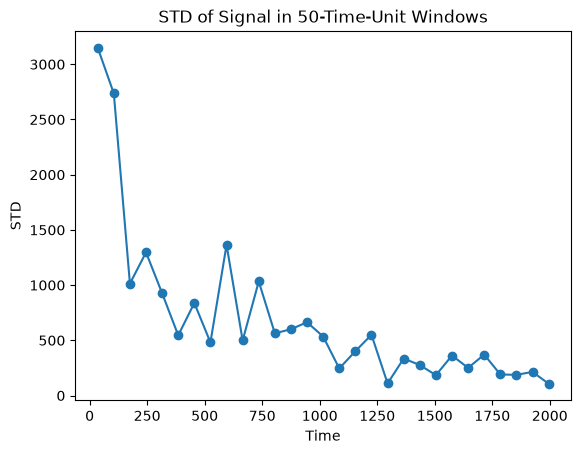

In [11]:
stds = signal_std_by_time(data[155, 16, :], Z, window = 70)
windows = list(stds.keys())
values = list(stds.values())

centers = [(start + end) / 2 for start, end in windows]

plt.plot(centers, values, marker="o")

plt.xlabel("Time")
plt.ylabel("STD")
plt.title("STD of Signal in 50-Time-Unit Windows")

plt.show()

In [28]:
import numpy as np


def local_std_ratio(signal, accuracy):

    if signal.ndim != 1:
        raise ValueError("سیگنال باید یک بعدی باشد")

    if not np.all(np.isfinite(signal)):
        raise ValueError("signal شامل مقادیر نامعتبر است")

    if accuracy not in range(1, 41):
        raise ValueError("دقت باید بین 1 تا 40 باشد")

    small_size = accuracy

    left = accuracy * 2
    right = accuracy * 2

    n = len(signal)

    small_starts = np.arange(0,n,small_size)
    small_ends = np.minimum(small_starts + small_size,n)

    big_starts = np.maximum(0,small_starts - left)
    big_ends = np.minimum(small_ends + right,n)

    cumsum = np.concatenate(([0], np.cumsum(signal)))

    cumsum_sq = np.concatenate(([0], np.cumsum(signal ** 2)))

    small_sums = (cumsum[small_ends] - cumsum[small_starts])

    small_sums_sq = (cumsum_sq[small_ends] - cumsum_sq[small_starts])

    small_lengths = (small_ends - small_starts)

    small_means = (small_sums / small_lengths)

    small_variances = (small_sums_sq / small_lengths - small_means ** 2)

    small_variances = np.maximum(small_variances, 0)

    small_stds = np.sqrt(small_variances)

    big_sums = (cumsum[big_ends] - cumsum[big_starts])

    big_sums_sq = (cumsum_sq[big_ends] - cumsum_sq[big_starts])

    big_lengths = (big_ends - big_starts)

    big_means = (big_sums / big_lengths)

    big_variances = (big_sums_sq / big_lengths - big_means ** 2)

    big_variances = np.maximum(big_variances, 0)

    big_stds = np.sqrt(big_variances)

    ratios = np.divide(
        small_stds,
        big_stds,
        out=np.full_like(
            small_stds,
            np.nan,
            dtype=float
        ),
        where=big_stds != 0
    )

    return ratios

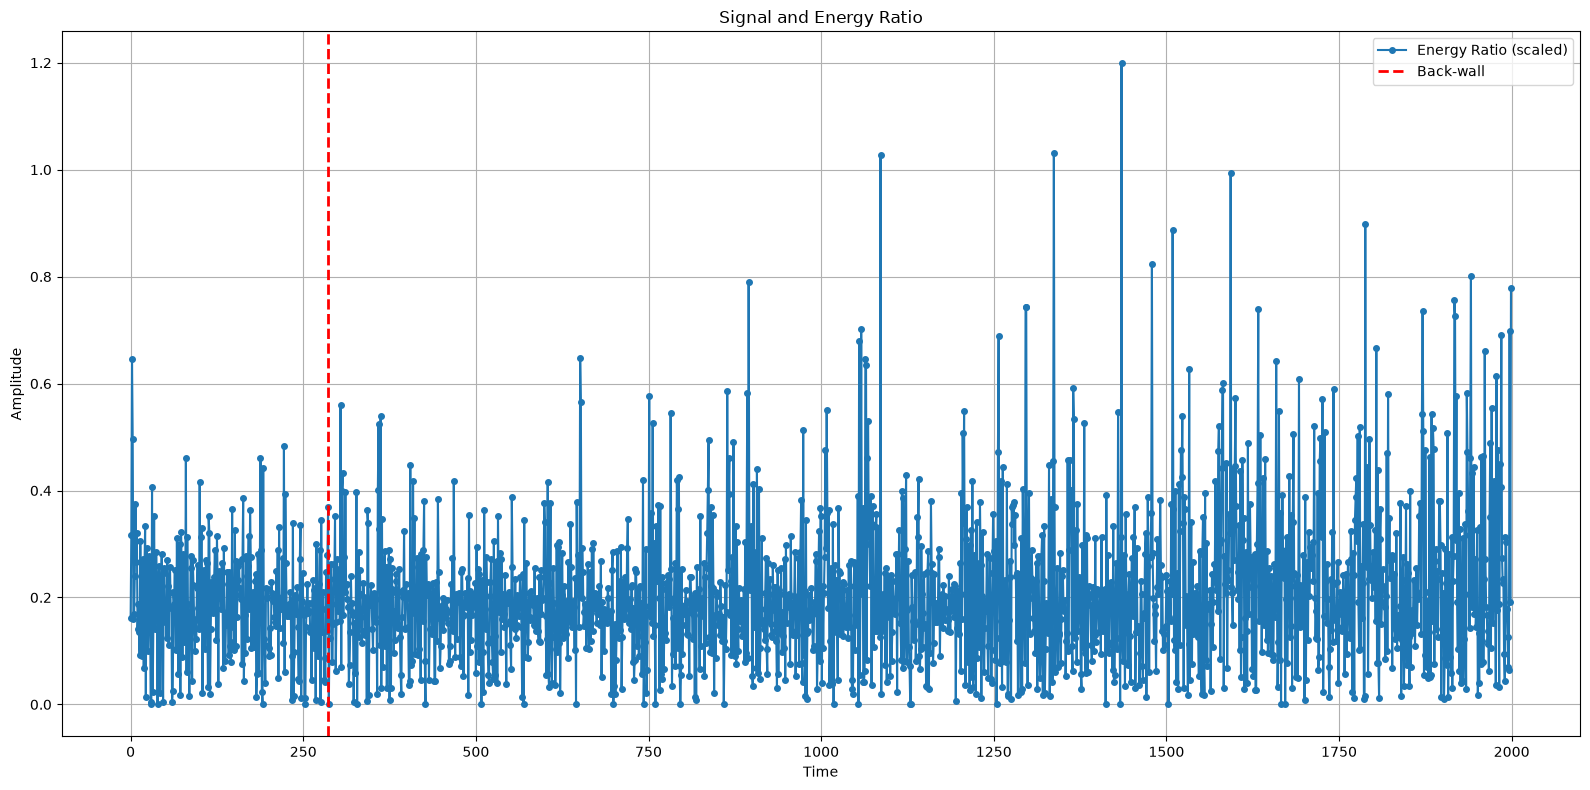

In [32]:
signal = data[25, 6, :]

plt.figure(figsize=(16, 8))


y = local_std_ratio(signal, 2)

plt.plot(

    y,
    marker="o",
    markersize=4,
    label="Energy Ratio (scaled)"
)

plt.axvline(
        285.65,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Back-wall'
    )

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Signal and Energy Ratio")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

In [26]:
def local_power_ratio(signal, accuracy):

    if power.ndim != 1:
        raise ValueError("سیگنال باید یک بعدی باشد")

    if not np.all(np.isfinite(power)):
        raise ValueError("signal شامل مقادیر نامعتبر است")

    if not accuracy in range(1,41):
        raise ValueError("دقت باید بین یک تا چهل باشد.")

    power = signal ** 2

    small_size = accuracy

    left = accuracy * 2
    right = accuracy * 2

    n = len(power)

    small_starts = np.arange(0, n, small_size)
    small_ends = np.minimum(small_starts + small_size,n)

    big_starts = np.maximum(0,small_starts - left)
    big_ends = np.minimum(n,small_ends + right)

    cumsum = np.concatenate(([0], np.cumsum(power)))

    small_sums = (cumsum[small_ends]- cumsum[small_starts])
    small_lengths = (small_ends - small_starts)
    small_means = (small_sums / small_lengths)

    big_sums = (cumsum[big_ends] - cumsum[big_starts])
    big_lengths = (big_ends - big_starts)
    big_means = (big_sums / big_lengths)

    ratios = np.divide(
        small_means,
        big_means,
        out=np.zeros_like(small_means),
        where=big_means != 0
    )

    return ratios